/home/hwx/envs/boron/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


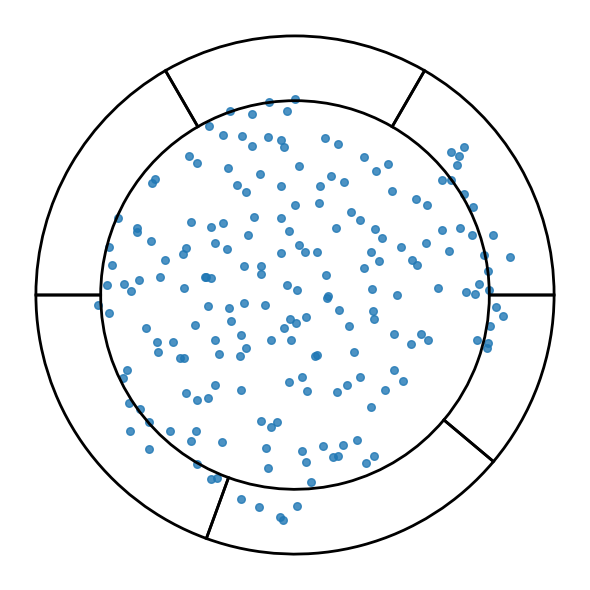

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
import umap

# ===== 模拟数据 =====
np.random.seed(42)
data = np.random.randn(200, 50)

# ===== UMAP降维 =====
reducer = umap.UMAP(metric="cosine", random_state=42)
emb_2d = reducer.fit_transform(data)

# ===== 计算中心 =====
center_x = emb_2d[:,0].mean()
center_y = emb_2d[:,1].mean()

dist = np.sqrt((emb_2d[:,0]-center_x)**2 + (emb_2d[:,1]-center_y)**2)
radius = dist.max() * 1.15

# ===== 扇形角度（可以自由修改）=====
# 每个元素是 (start_angle, end_angle)
sectors = [
    (0, 60),
    (60, 120),
    (120, 180),
    (180, 250),
    (250, 320),
    (320, 360)
]

# ===== 画图 =====
fig, ax = plt.subplots(figsize=(6,6))

# UMAP散点
ax.scatter(emb_2d[:,0], emb_2d[:,1], s=30, alpha=0.8)

# 画扇形环
for start, end in sectors:
    wedge = Wedge(
        (center_x, center_y),  # 圆心
        radius,                # 外半径
        start,                 # 起始角
        end,                   # 结束角
        width=radius*0.25,     # 环宽
        edgecolor="black",
        facecolor="none",
        linewidth=2
    )
    ax.add_patch(wedge)

# ===== 去掉坐标轴 =====
ax.axis("off")

plt.tight_layout()
plt.show()